<a href="https://colab.research.google.com/github/PrashantBagri/IP_IIIT_Delhi_2026/blob/main/input_hidden_discretized_pb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tempfile
import os

import tensorflow as tf
from tensorflow import keras

In [2]:
import numpy as np
import tensorflow as tf

try:
    import tf_keras as keras
except ImportError:
    from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# Load MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Match paper setup: use 50k training samples
x_train = x_train_full[:50000]
y_train = y_train_full[:50000]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

11490434/11490434 [==============================] - 0s 0us/step
Train: (50000, 28, 28) (50000,)
Test : (10000, 28, 28) (10000,)


In [4]:
def build_float_ann():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="sigmoid"),
        keras.layers.Dense(10)   # logits
    ])
    return model

float_model = build_float_ann()
float_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
float_model = build_float_ann()

float_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Train model
float_history = float_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=32,
    verbose=1
)

float_test_loss, float_test_acc = float_model.evaluate(x_test, y_test, verbose=0)

print(f"FLOAT Test accuracy: {float_test_acc:.4f} | loss: {float_test_loss:.4f}")

Epoch 1/40
1563/1563 [==============================] - 14s 8ms/step - loss: 0.4357 - accuracy: 0.8870
Epoch 2/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.2147 - accuracy: 0.9382
Epoch 3/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.1602 - accuracy: 0.9539
Epoch 4/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1269 - accuracy: 0.9629
Epoch 5/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1028 - accuracy: 0.9709
Epoch 6/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0851 - accuracy: 0.9756
Epoch 7/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0706 - accuracy: 0.9800
Epoch 8/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0594 - accuracy: 0.9839
Epoch 9/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0503 - accuracy: 0.9869
Epoch 10/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.04

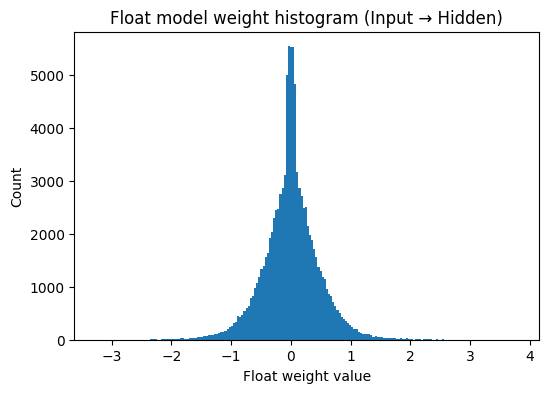

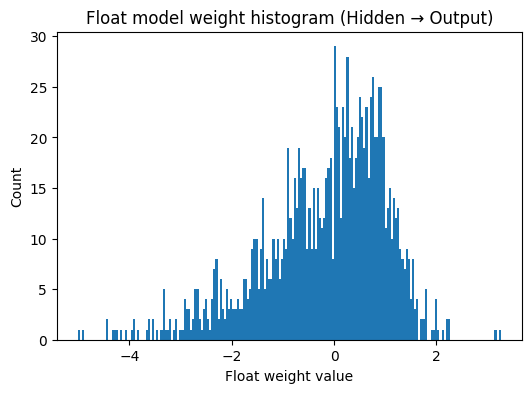

In [6]:
import matplotlib.pyplot as plt

dense_layers = []

for layer in float_model.layers:

    if isinstance(layer, keras.layers.Dense):
        dense_layers.append(layer)

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
# plt.xlim([-4, 4])
plt.show()

w2 = dense_layers[1].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()

In [7]:
print("******** Non discretized weights for input to hidden layer ************ \n\n")

layer_weights1, biases1 = dense_layers[0].get_weights()
print(layer_weights1)
#weights only for one layer

******** Non discretized weights for input to hidden layer ************ 


[[ 0.02802125 -0.01971118  0.03647815 ...  0.03448527  0.00083263
  -0.01016307]
 [ 0.00337049 -0.04661984  0.07310804 ...  0.02996398 -0.02744739
   0.06612051]
 [ 0.01364595 -0.042668    0.06245253 ... -0.01056175 -0.02860196
  -0.04363159]
 ...
 [ 0.02618698  0.0521869  -0.01766092 ...  0.01346087 -0.00955312
  -0.05609037]
 [ 0.01699794 -0.0454763  -0.029134   ...  0.07462605 -0.02177568
   0.07559318]
 [-0.03755496 -0.06027054 -0.00338025 ...  0.05080498 -0.01450191
   0.05343289]]


In [8]:
levels1 = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]
levels2 = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]


def snap_weights_to_levels(weights, levels):


    levels = np.array(levels)
    snapped = np.zeros_like(weights)

    for i in range(weights.shape[0]):
        for j in range(weights.shape[1]):
            w = weights[i, j]


            if w <= levels[0]:
                snapped[i, j] = levels[0]
                continue
            if w >= levels[-1]:
                snapped[i, j] = levels[-1]
                continue


            for k in range(len(levels) - 1):
                low = levels[k]
                high = levels[k + 1]

                if low <= w <= high:
                    midpoint = (low + high) / 2

                    if w > midpoint:
                        snapped[i, j] = high
                    else:
                        snapped[i, j] = low
                    break

    return snapped


In [9]:
snapped_weights1 = snap_weights_to_levels(layer_weights1, levels1)

In [10]:
print("\n\n")
print(snapped_weights1)




[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [11]:
dense_layers[0].set_weights([snapped_weights1, biases1])

In [12]:
loss, acc = float_model.evaluate(x_test, y_test)
print("Accuracy:", acc)

313/313 [==============================] - 1s 3ms/step - loss: 0.1582 - accuracy: 0.9667
Accuracy: 0.96670001745224


In [13]:
float_history = float_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
1563/1563 [==============================] - 8s 5ms/step - loss: 0.0038 - accuracy: 0.9989
Epoch 2/5
1563/1563 [==============================] - 5s 3ms/step - loss: 4.0384e-04 - accuracy: 1.0000
Epoch 3/5
1563/1563 [==============================] - 5s 3ms/step - loss: 2.9458e-04 - accuracy: 1.0000
Epoch 4/5
1563/1563 [==============================] - 5s 3ms/step - loss: 3.1146e-04 - accuracy: 1.0000
Epoch 5/5
1563/1563 [==============================] - 4s 3ms/step - loss: 3.3494e-04 - accuracy: 1.0000


In [14]:
loss, acc = float_model.evaluate(x_test, y_test)
print("Accuracy:", acc)

313/313 [==============================] - 1s 3ms/step - loss: 0.1071 - accuracy: 0.9776
Accuracy: 0.9775999784469604


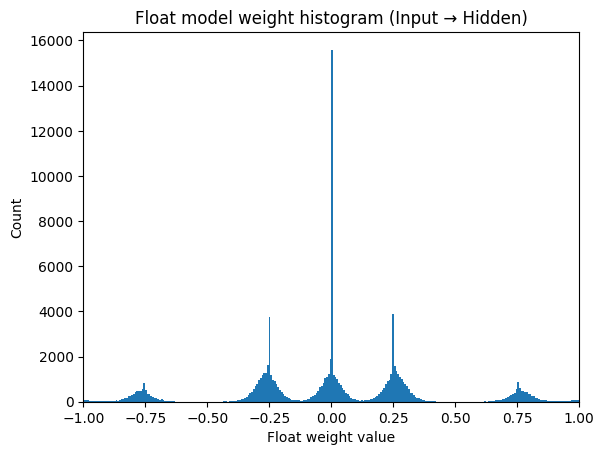

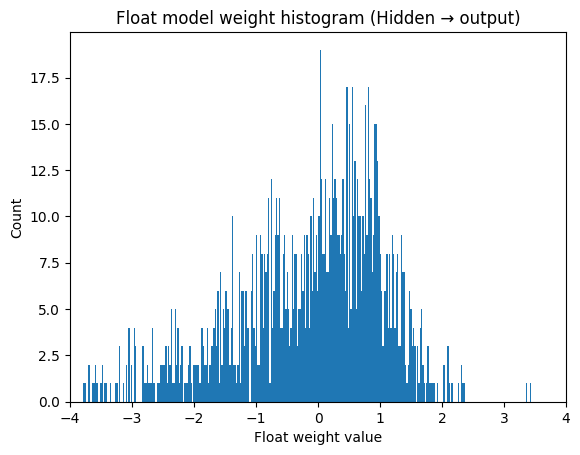

In [16]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)
w2 = dense_layers[1].get_weights()[0].reshape(-1)


plt.hist(w1, bins=400)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
plt.xlim([-1, 1])
plt.show()

plt.hist(w2, bins=400)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → output)")
plt.xlim([-4, 4])
plt.show()

Input to hiddem is discretized only